In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version

In [2]:
adata_orig = sc.read_h5ad("output/adata_orig_umap.h5ad")
adata_ft   = sc.read_h5ad("output/adata_ft_whole_umap.h5ad")
adata_st   = sc.read_h5ad("output/adata_st_whole_umap.h5ad")

In [3]:
# Load annotations
supervised_df = pd.read_excel(
    "data/breast_cancer_xenium_celltype_supervised.xlsx"
)[["Barcode", "Cluster"]].rename(
    columns={"Cluster": "cluster_supervised"}
)

unsupervised_df = pd.read_excel(
    "data/breast_cancer_xenium_celltype_unsupervised.xlsx"
)[["Barcode", "ident"]].rename(
    columns={"ident": "cluster_unsupervised"}
)

for df in (supervised_df, unsupervised_df):
    df["Barcode"] = (
        df["Barcode"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

def add_annotations(adata):
    obs = adata.obs.copy()

    # obs_names → Barcode (string)
    obs["Barcode"] = obs.index.astype(str)

    obs = (
        obs
        .merge(supervised_df, on="Barcode", how="left")
        .merge(unsupervised_df, on="Barcode", how="left")
        .set_index("Barcode")
    )

    adata.obs = obs
    return adata


# Apply to all AnnData objects
adata_orig = add_annotations(adata_orig)
adata_st = add_annotations(adata_st)
adata_ft = add_annotations(adata_ft)

In [4]:
np.unique(adata_orig.obs['cluster_supervised'])

array(['B_Cells', 'CD4+_T_Cells', 'CD8+_T_Cells', 'DCIS_1', 'DCIS_2',
       'Endothelial', 'IRF7+_DCs', 'Invasive_Tumor', 'LAMP3+_DCs',
       'Macrophages_1', 'Macrophages_2', 'Mast_Cells', 'Myoepi_ACTA2+',
       'Myoepi_KRT15+', 'Perivascular-Like', 'Prolif_Invasive_Tumor',
       'Stromal', 'Stromal_&_T_Cell_Hybrid', 'T_Cell_&_Tumor_Hybrid',
       'Unlabeled'], dtype=object)

In [5]:
# ---- Filtering helpers ----
BAD = {"Stromal_&_T_Cell_Hybrid", "T_Cell_&_Tumor_Hybrid", "Unlabeled"}

def filter_celltypes(adata, key="cluster_supervised", bad=BAD, min_cells_per_cluster=20):
    """
    Removes cells with 'bad' labels in adata.obs[key] and drops clusters with < min_cells_per_cluster cells.
    Returns a *new* AnnData view copied into memory.
    """
    if key not in adata.obs:
        raise KeyError(f"obs['{key}'] not found. Available keys: {list(adata.obs.columns)[:20]} ...")

    # 1) remove bad labels
    keep = ~adata.obs[key].isin(bad)
    ad = adata[keep].copy()

    # 2) remove NA/empty labels just in case
    ad = ad[~ad.obs[key].isna()].copy()
    ad = ad[ad.obs[key].astype(str).str.len() > 0].copy()

    # 3) drop tiny clusters (ligrec permutation test gets weird with very small groups)
    vc = ad.obs[key].value_counts()
    keep_clusters = vc[vc >= min_cells_per_cluster].index
    ad = ad[ad.obs[key].isin(keep_clusters)].copy()

    # make categorical for speed/consistency
    ad.obs[key] = ad.obs[key].astype("category")
    return ad


def run_ligrec(adata, cluster_key="celltype_mapped_refined", n_perms=1000, threshold=0.1):
    """
    Runs Squidpy ligand-receptor permutation test.
    Stores result in adata.uns['ligrec'] (copy=True returns a modified copy).
    """
    if cluster_key not in adata.obs:
        raise KeyError(f"obs['{cluster_key}'] not found. Available keys: {list(adata.obs.columns)[:20]} ...")

    res = sq.gr.ligrec(
        adata,
        n_perms=n_perms,
        cluster_key=cluster_key,
        copy=True,
        use_raw=False,
        threshold=threshold,
        transmitter_params={"categories": "ligand"},
        receiver_params={"categories": "receptor"},
        seed = 0
    )
    return res


In [6]:
# remove hybrids/unlabeled using cluster_supervised
adata_orig_f = filter_celltypes(adata_orig, key="cluster_supervised", bad=BAD, min_cells_per_cluster=20)
adata_st_f   = filter_celltypes(adata_st,   key="cluster_supervised", bad=BAD, min_cells_per_cluster=20)
adata_ft_f   = filter_celltypes(adata_ft,   key="cluster_supervised", bad=BAD, min_cells_per_cluster=20)

In [7]:
# run ligrec consistently
res_orig2 = run_ligrec(adata_orig_f, cluster_key="cluster_supervised", n_perms=100, threshold=0.0)
res_st2   = run_ligrec(adata_st_f,   cluster_key="cluster_supervised", n_perms=100, threshold=0.0)
res_ft2   = run_ligrec(adata_ft_f,   cluster_key="cluster_supervised", n_perms=100, threshold=0.0)

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/numba/parfors/parfor.py:2399: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more than one entry to or exit from the loop (e.g., an assertion).

File "/Users/lyuan13/Desktop/HOT-NERD/tutorials/breast_cancer", line 33:
<source missing, REPL/exec in use?>

  warnings.warn(
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and

In [8]:
def inspect_ligrec_dict(res):
    print("keys:", list(res.keys()))
    means = res["means"]
    pvals = res["pvalues"]

    print("means shape:", means.shape, "pvalues shape:", pvals.shape)

    means_np = means.to_numpy(dtype=float, copy=False)
    pvals_np = pvals.to_numpy(dtype=float, copy=False)

    print("means finite fraction:", np.isfinite(means_np).mean())
    print("pvals finite fraction:", np.isfinite(pvals_np).mean())

    print("means all-NaN rows:", int(np.isnan(means_np).all(axis=1).sum()), "/", means.shape[0])
    print("pvals all-NaN rows:", int(np.isnan(pvals_np).all(axis=1).sum()), "/", pvals.shape[0])

    # show a small preview
    print("\nmeans head:")
    display(means.head())
    print("\npvalues head:")
    display(pvals.head())

inspect_ligrec_dict(res_orig2)


keys: ['means', 'pvalues', 'metadata']
means shape: (81, 289) pvalues shape: (81, 289)
means finite fraction: 1.0
pvals finite fraction: 0.9789397240377633
means all-NaN rows: 0 / 81
pvals all-NaN rows: 0 / 81

means head:


cluster_1       B_Cells                                                \
cluster_2       B_Cells CD4+_T_Cells CD8+_T_Cells    DCIS_1    DCIS_2   
source target                                                           
CD80   CTLA4   0.046869     0.237304     0.123264  0.032707  0.033102   
IGF1   ESR1    0.146098     0.123695     0.123458  0.279076  0.238734   
CXCL12 CXCR4   1.068429     1.279672     1.212422  0.398243  0.421696   
EDN1   EDNRB   0.022426     0.022287     0.019223   0.00702  0.006868   
CD274  PDCD1   0.013223     0.017771      0.01712  0.012232  0.012397   

cluster_1                                                                    \
cluster_2     Endothelial IRF7+_DCs Invasive_Tumor LAMP3+_DCs Macrophages_1   
source target                                                                 
CD80   CTLA4     0.044465  0.048825       0.033274   0.100027      0.066988   
IGF1   ESR1      0.128657  0.120999       0.147775   0.118424      0.133849   
CXCL12 CXCR4     0.527625  1.330467       0.495297   1.231775      0.856065   
EDN1   EDNRB     0.172486  0.024434       0.008543   0.018808      0.024119   
CD274  PDCD1     0.012412         0       0.012328          0      0.012896   

cluster_1      ...        Stromal                                         \
cluster_2      ... Invasive_Tumor LAMP3+_DCs Macrophages_1 Macrophages_2   
source target  ...                                                         
CD80   CTLA4   ...       0.010015   0.076768      0.043729      0.026673   
IGF1   ESR1    ...       0.320414   0.291064      0.306488       0.31647   
CXCL12 CXCR4   ...       0.794864   1.531341      1.155631      0.946724   
EDN1   EDNRB   ...       0.010259   0.020523      0.025835      0.031491   
CD274  PDCD1   ...       0.010844          0      0.011412       0.01133   

cluster_1                                                               \
cluster_2     Mast_Cells Myoepi_ACTA2+ Myoepi_KRT15+ Perivascular-Like   
source target                                                            
CD80   CTLA4    0.012414      0.015765      0.011257          0.024115   
IGF1   ESR1     0.319212      0.343192      0.310215          0.308727   
CXCL12 CXCR4    0.878944      0.741905      0.723237          0.806708   
EDN1   EDNRB    0.044382      0.016398      0.007418          0.205877   
CD274  PDCD1           0      0.010787      0.010739                 0   

cluster_1                                      
cluster_2     Prolif_Invasive_Tumor   Stromal  
source target                                  
CD80   CTLA4                0.01002  0.047527  
IGF1   ESR1                0.328908  0.313268  
CXCL12 CXCR4               0.833932  0.950623  
EDN1   EDNRB                0.00975  0.081318  
CD274  PDCD1               0.010807  0.011719  

[5 rows x 289 columns]


pvalues head:


cluster_1     B_Cells                                                      \
cluster_2     B_Cells CD4+_T_Cells CD8+_T_Cells DCIS_1 DCIS_2 Endothelial   
source target                                                               
CD80   CTLA4      0.0          0.0          0.0    1.0    1.0         0.0   
IGF1   ESR1      0.78          1.0          1.0    0.0    0.0         1.0   
CXCL12 CXCR4      0.0          0.0          0.0    1.0    1.0         1.0   
EDN1   EDNRB      1.0          1.0          1.0    1.0    1.0         0.0   
CD274  PDCD1      0.0          0.0          0.0   0.02    0.0         0.0   

cluster_1                                                        ...  \
cluster_2     IRF7+_DCs Invasive_Tumor LAMP3+_DCs Macrophages_1  ...   
source target                                                    ...   
CD80   CTLA4       0.04            1.0        0.0           0.0  ...   
IGF1   ESR1         1.0           0.73        1.0           1.0  ...   
CXCL12 CXCR4        0.0            1.0        0.0           0.0  ...   
EDN1   EDNRB        1.0            1.0        1.0           1.0  ...   
CD274  PDCD1        NaN            0.0        NaN           0.0  ...   

cluster_1            Stromal                                         \
cluster_2     Invasive_Tumor LAMP3+_DCs Macrophages_1 Macrophages_2   
source target                                                         
CD80   CTLA4             1.0        0.0           0.0           1.0   
IGF1   ESR1              0.0        0.0           0.0           0.0   
CXCL12 CXCR4             0.0        0.0           0.0           0.0   
EDN1   EDNRB             1.0        1.0           1.0           1.0   
CD274  PDCD1             0.0        NaN           0.0          0.01   

cluster_1                                                               \
cluster_2     Mast_Cells Myoepi_ACTA2+ Myoepi_KRT15+ Perivascular-Like   
source target                                                            
CD80   CTLA4         1.0           1.0           1.0               1.0   
IGF1   ESR1          0.0           0.0           0.0               0.0   
CXCL12 CXCR4         0.0           0.0           0.0               0.0   
EDN1   EDNRB         0.5           1.0           1.0               0.0   
CD274  PDCD1         NaN          0.01          0.04               NaN   

cluster_1                                    
cluster_2     Prolif_Invasive_Tumor Stromal  
source target                                
CD80   CTLA4                    1.0     0.0  
IGF1   ESR1                     0.0     0.0  
CXCL12 CXCR4                    0.0     0.0  
EDN1   EDNRB                    1.0     0.0  
CD274  PDCD1                   0.03     0.0  

[5 rows x 289 columns]

In [9]:
from statsmodels.stats.multitest import multipletests

def fdr_correct_ligrec(res):
    pvals = res["pvalues"].copy()

    # Flatten non-NaN p-values
    arr = pvals.to_numpy(dtype=float)
    mask = np.isfinite(arr)
    p_flat = arr[mask]

    # FDR correction
    _, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")

    # Reconstruct matrix
    qvals = arr.copy()
    qvals[mask] = q_flat
    qvals_df = pd.DataFrame(qvals, index=pvals.index, columns=pvals.columns)

    return qvals_df

qvals_orig = fdr_correct_ligrec(res_orig2)
qvals_st   = fdr_correct_ligrec(res_st2)
qvals_ft   = fdr_correct_ligrec(res_ft2)

# Make FDR-aware copies of the result dicts
res_orig_fdr = res_orig2.copy()
res_st_fdr   = res_st2.copy()
res_ft_fdr   = res_ft2.copy()

res_orig_fdr["pvalues"] = qvals_orig
res_st_fdr["pvalues"]   = qvals_st
res_ft_fdr["pvalues"]   = qvals_ft

In [10]:
def build_edge_count_matrix(res, alpha=0.05):
    """
    Build a sender→receiver matrix of counts of significant LR interactions.

    Works whether res["means"].columns are:
      - strings like "Sender|Receiver"
      - or tuples / MultiIndex with (Sender, Receiver, ...)
    """
    means = res["means"]
    pvals = res["pvalues"]

    sig = (pvals < alpha)

    senders = []
    receivers = []

    # collect all unique sender/receiver names
    for col in means.columns:
        if isinstance(col, tuple):
            # 
            sender, receiver = col[0], col[1]
        else:
            # string case: "Sender|Receiver"
            sender, receiver = col.split("|")
        senders.append(sender)
        receivers.append(receiver)

    clusters = sorted(set(senders) | set(receivers))

    # Initialize matrix
    C = pd.DataFrame(0, index=clusters, columns=clusters, dtype=int)

    # fill counts
    for col in means.columns:
        if isinstance(col, tuple):
            sender, receiver = col[0], col[1]
        else:
            sender, receiver = col.split("|")

        C.loc[sender, receiver] += sig[col].sum()

    return C

# Build edge-count matrices using p<0.05
#C_orig = build_edge_count_matrix(res_orig2, alpha=0.05)
#C_st   = build_edge_count_matrix(res_st2,   alpha=0.05)
#C_ft   = build_edge_count_matrix(res_ft2,   alpha=0.05)

# Build edge-count matrices using FDR<0.05
C_orig = build_edge_count_matrix(res_orig_fdr, alpha=0.05)
C_st   = build_edge_count_matrix(res_st_fdr,   alpha=0.05)
C_ft   = build_edge_count_matrix(res_ft_fdr,   alpha=0.05)

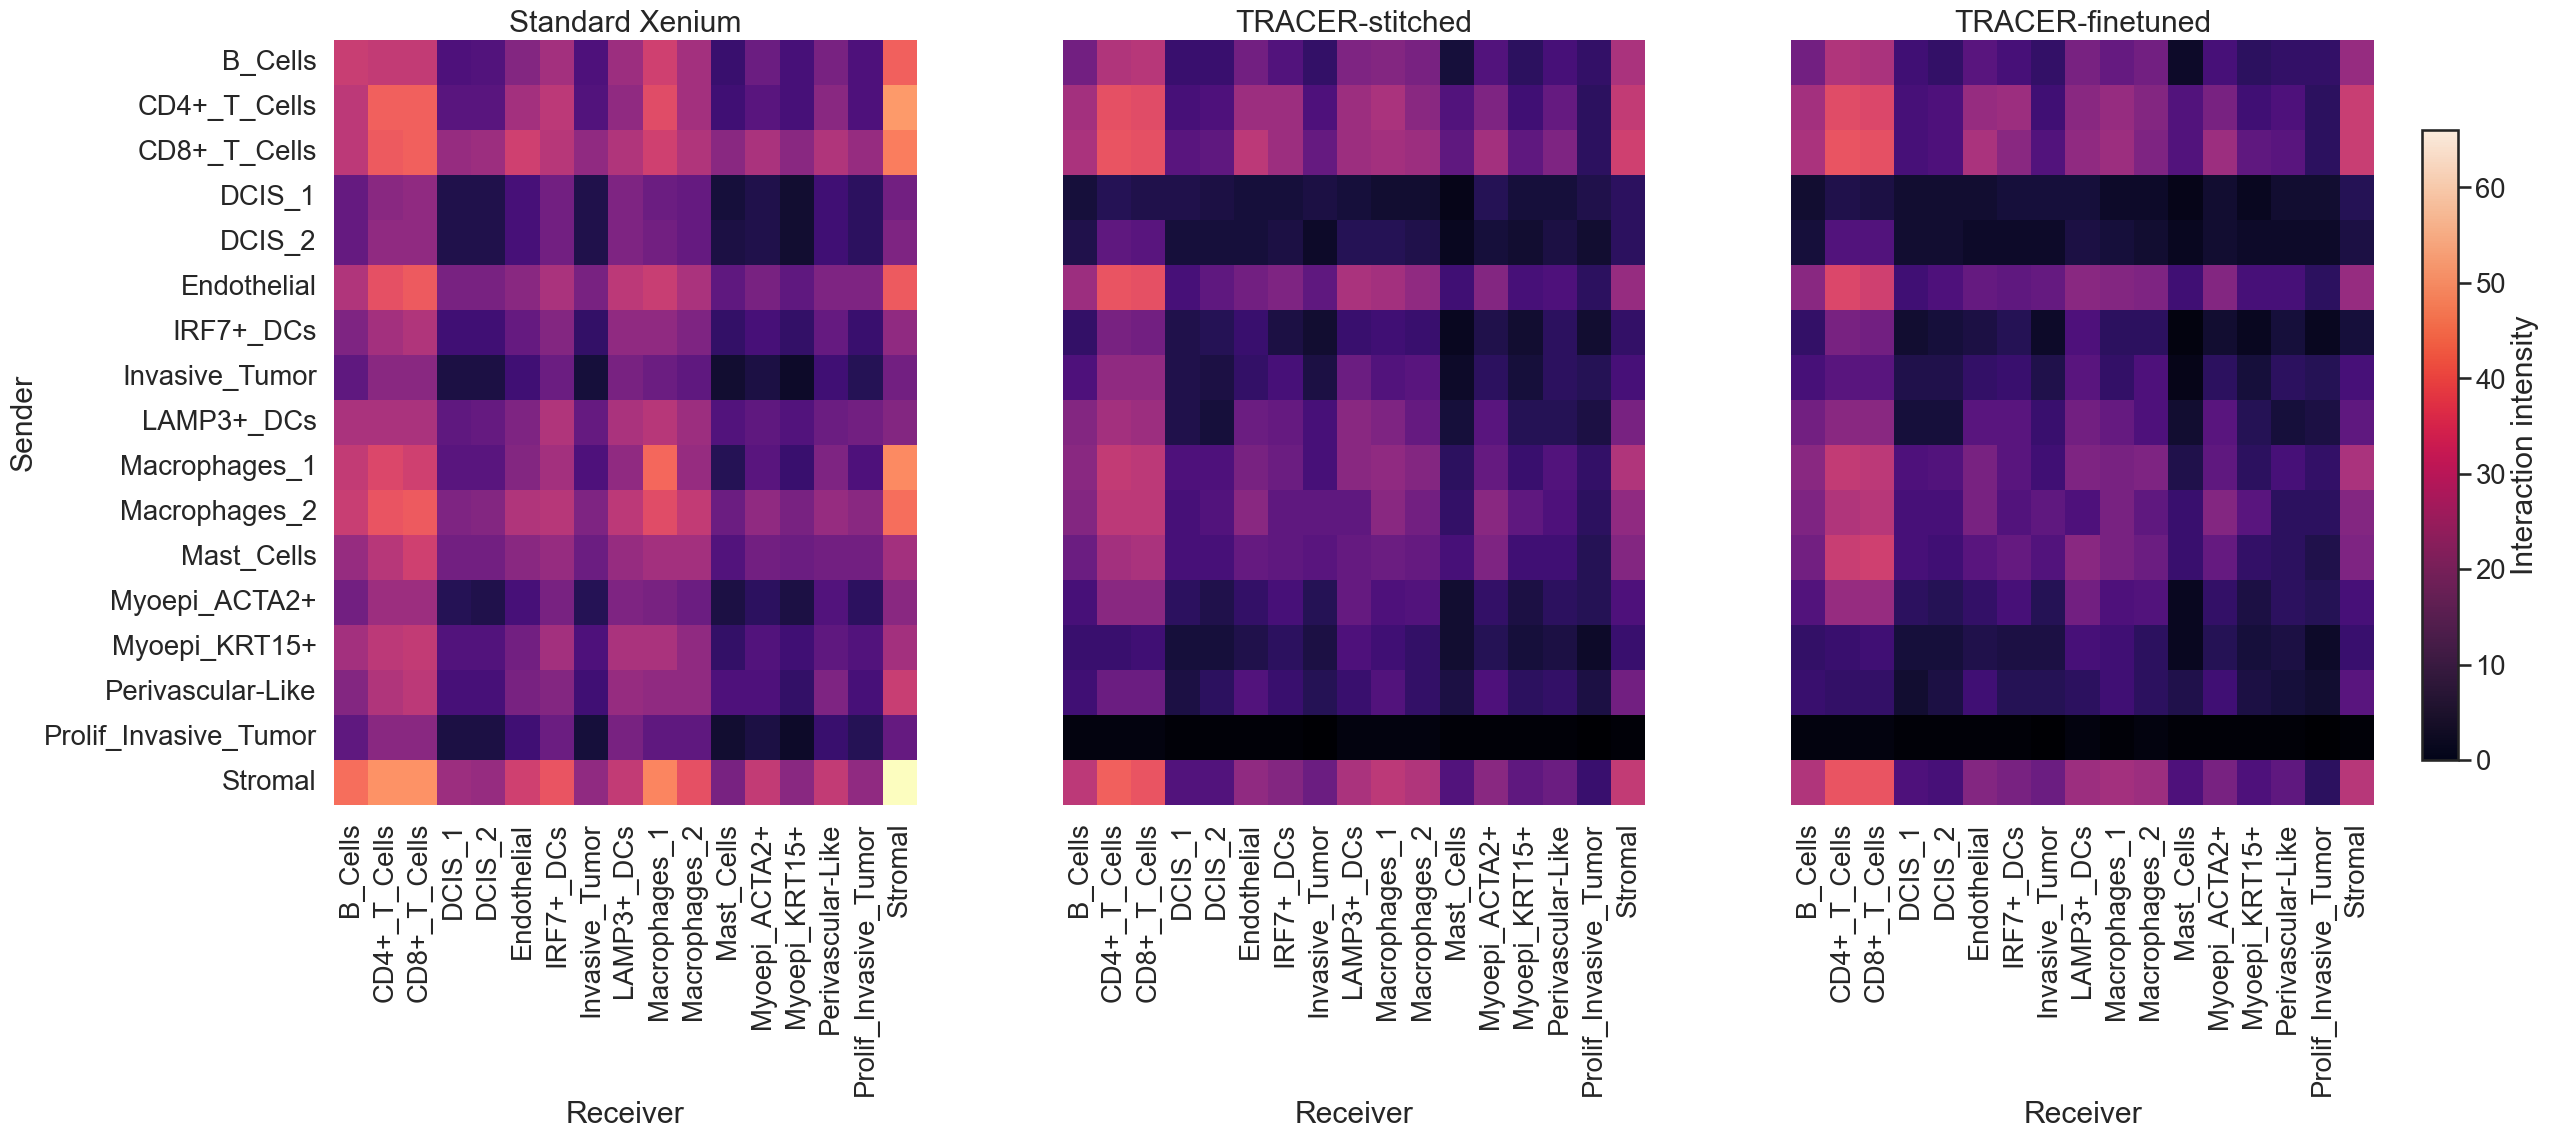

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="talk", style="white", font_scale=1.2)

# Example: 3 heatmaps
conditions = {
    "Standard Xenium": C_orig,
    "TRACER-stitched": C_st,
    "TRACER-finetuned": C_ft,
}

# Global color limits
vmin = min(C_orig.values.min(), C_st.values.min(), C_ft.values.min())
vmax = max(C_orig.values.max(), C_st.values.max(), C_ft.values.max())

# Create figure with extra width for colorbar
fig, axes = plt.subplots(1, 3, figsize=(24, 9), sharex=True, sharey=True)

# Plot heatmaps without individual colorbars
for ax, (label, C) in zip(axes, conditions.items()):
    sns.heatmap(C, cmap="magma", ax=ax, vmin=vmin, vmax=vmax, cbar=False)
    ax.set_title(label)
    ax.set_xlabel("Receiver")
    ax.set_ylabel("Sender" if ax == axes[0] else "")

# Shared colorbar on the right
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])

# Explicit axes for colorbar (fraction of figure width)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Interaction intensity")

# Adjust layout manually (tight_layout can interfere with colorbar)
fig.subplots_adjust(left=0.05, right=0.9, top=0.95, bottom=0.1, wspace=0.25)

plt.savefig('plot/LR_interaction_heatmap.png', dpi=300)
plt.show()


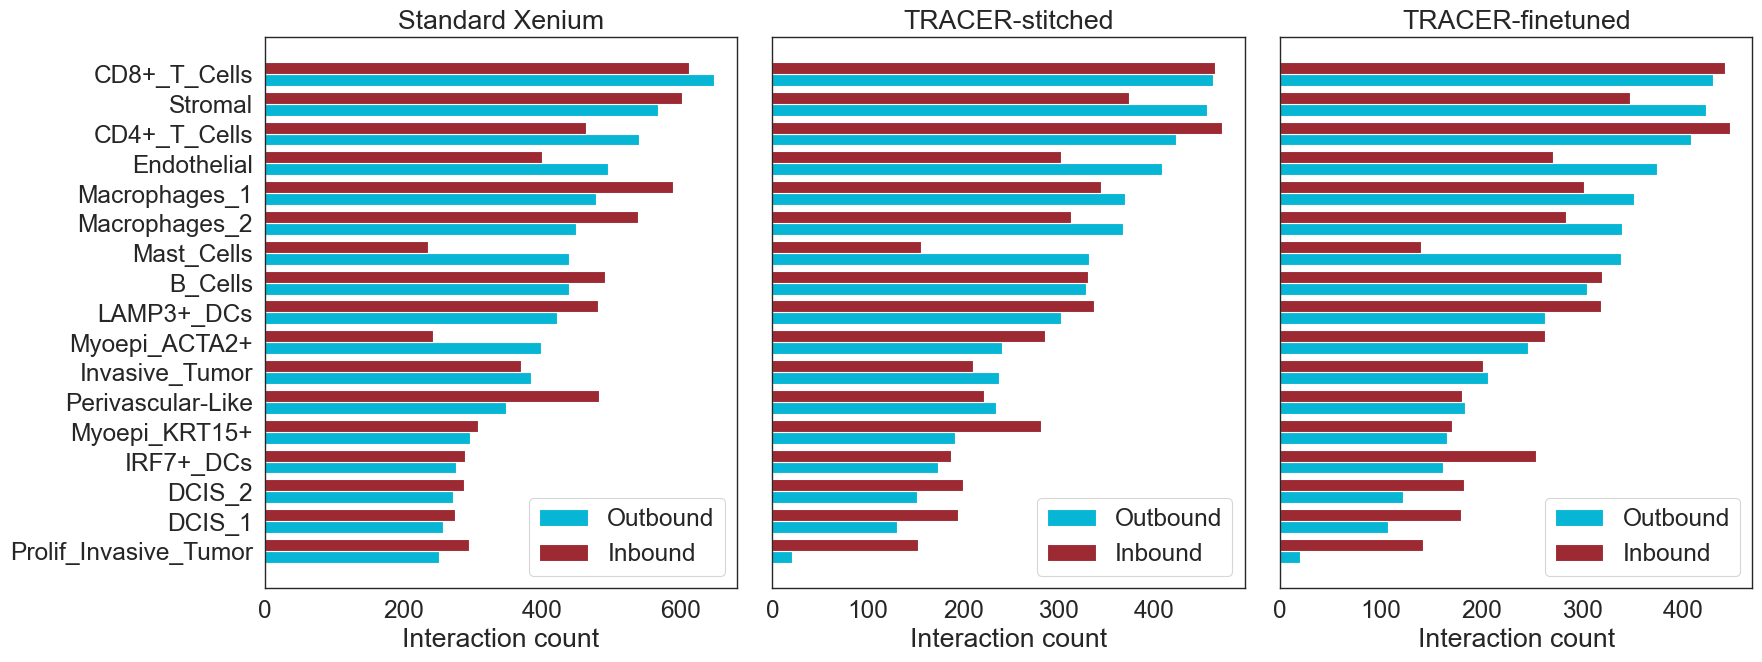

In [19]:
sns.set(style="white", context="paper", font_scale=2)

conditions = {
    "Standard Xenium": C_orig,
    "TRACER-stitched": C_st,
    "TRACER-finetuned": C_ft,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, (label, C) in zip(axes, conditions.items()):
    # Compute sums
    outbound = C.sum(axis=1)   # sender
    inbound  = C.sum(axis=0)   # receiver

    # Sort for nicer plotting
    outbound = outbound.sort_values()
    inbound = inbound.reindex(outbound.index)  # align indices

    # Bar positions
    y = np.arange(len(outbound))
    height = 0.4  # width of each bar

    # Plot bars side by side
    ax.barh(y - height/2, outbound.values, height=height, color="#06b6d4", label="Outbound")
    ax.barh(y + height/2, inbound.values,  height=height, color="#9d2933", label="Inbound")

    ax.set_yticks(y)
    ax.set_yticklabels(outbound.index)
    ax.set_xlabel("Interaction count")
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.savefig('plot/LR_interaction_barplot.png', dpi=300)
plt.show()

In [21]:
cluster_key = "cluster_supervised"

adata_orig_f.uns[f"{cluster_key}_ligrec"] = res_orig_fdr
adata_st_f.uns[f"{cluster_key}_ligrec"] = res_st_fdr
adata_ft_f.uns[f"{cluster_key}_ligrec"] = res_ft_fdr

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_ligrec.py:248: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
  if cluster_key not in adata.uns_keys():
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_3163/494566737.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


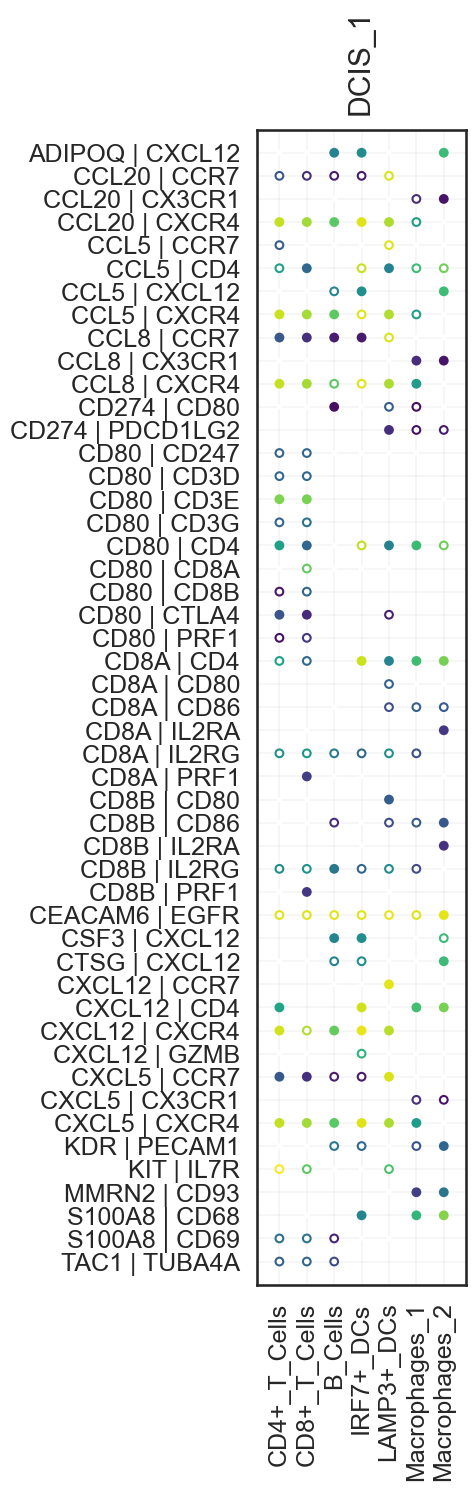

In [43]:
sns.set_theme(context="talk", style="white", font_scale=1.2)

sq.pl.ligrec(
    adata_orig_f,
    cluster_key="cluster_supervised",
    source_groups=["DCIS_1"],
    target_groups=[
        "CD4+_T_Cells", "CD8+_T_Cells", "B_Cells",
        "IRF7+_DCs", "LAMP3+_DCs",
        "Macrophages_1", "Macrophages_2"
    ],
    pvalue_threshold=0.01,
    alpha=0.01,
    remove_empty_interactions=True,
    remove_nonsig_interactions=True,
    swap_axes=False,
    title="",
    figsize=(3, 15),        
    save=None, 
    show=False
)
# Save figure
plt.tight_layout()
plt.savefig("original_ligrec_DCIS_publication.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_ligrec.py:248: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
  if cluster_key not in adata.uns_keys():
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_3163/1390473689.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


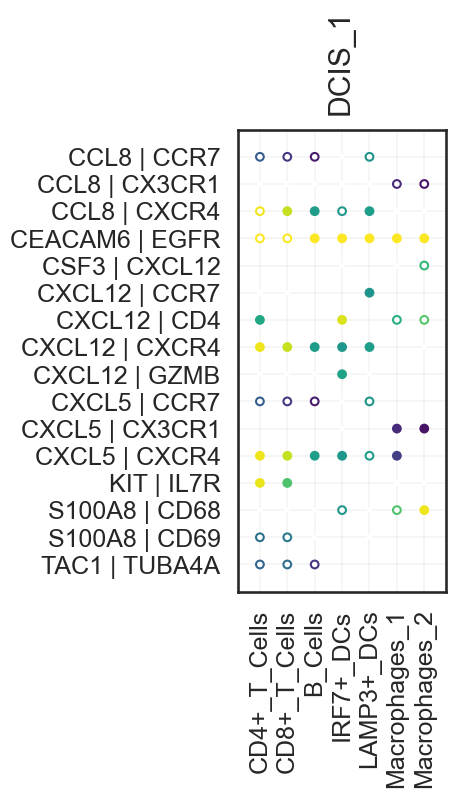

In [44]:
sns.set_theme(context="talk", style="white", font_scale=1.2)

sq.pl.ligrec(
    adata_st_f,
    cluster_key="cluster_supervised",
    source_groups=["DCIS_1"],
    target_groups=[
        "CD4+_T_Cells", "CD8+_T_Cells", "B_Cells",
        "IRF7+_DCs", "LAMP3+_DCs",
        "Macrophages_1", "Macrophages_2"
    ],
    pvalue_threshold=0.01,
    alpha=0.01,
    remove_empty_interactions=True,
    remove_nonsig_interactions=True,
    swap_axes=False,
    title="",
    figsize=(3, 6),        
    save=None, 
    show=False
)
# Save figure
plt.tight_layout()
plt.savefig("stitched_ligrec_DCIS_publication.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/squidpy/pl/_ligrec.py:248: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
  if cluster_key not in adata.uns_keys():
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_3163/14046382.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


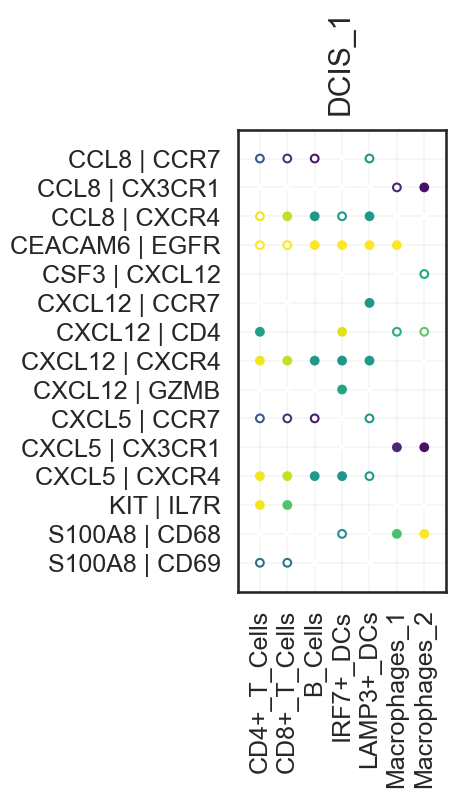

In [45]:
sns.set_theme(context="talk", style="white", font_scale=1.2)

sq.pl.ligrec(
    adata_ft_f,
    cluster_key="cluster_supervised",
    source_groups=["DCIS_1"],
    target_groups=[
        "CD4+_T_Cells", "CD8+_T_Cells", "B_Cells",
        "IRF7+_DCs", "LAMP3+_DCs",
        "Macrophages_1", "Macrophages_2"
    ],
    pvalue_threshold=0.01,
    alpha=0.01,
    remove_empty_interactions=True,
    remove_nonsig_interactions=True,
    swap_axes=False,
    title="",
    figsize=(3, 6),        
    save=None, 
    show=False
)
# Save figure
plt.tight_layout()
plt.savefig("finetuned_ligrec_DCIS_publication.png", dpi=300, bbox_inches="tight")
plt.show()